In [13]:
import time
import torch
import matplotlib.pyplot as plt
from IPython.display import clear_output

from data_module import InContextDataGenerator
from model_module import VectorICLTransformer
from training_module import TrainConfig, Trainer


In [14]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device =", device)

# Problem dimension
d = 20

# Training settings (start small in a workshop)
total_steps = 200_000
batch_size = 64
lr = 1e-4

# Model size (smaller than paper = easier to run live)
d_model = 256
n_layers = 12
n_heads = 8
max_seq_len = 256

# Curriculum task
task = "linear"          # or "sparse_linear"
sparse_s = 3             # only used if task="sparse_linear"

# Progress / plotting
log_every = 200          # print every N steps
plot_every = 500         # redraw plot every N steps
grad_clip = 1.0


device = cuda


In [15]:
# data generator
gen = InContextDataGenerator(d=d, device=device, seed=0)

# model
model = VectorICLTransformer(
    d_in=d,
    d_model=d_model,
    n_layers=n_layers,
    n_heads=n_heads,
    dropout=0.0,
    max_seq_len=max_seq_len,
).to(device)

# training config
cfg = TrainConfig(
    task=task,
    total_steps=total_steps,
    batch_size=batch_size,
    lr=lr,
    grad_clip=grad_clip,
    log_every=log_every,
    device=device,
)

trainer = Trainer(model=model, data_gen=gen, cfg=cfg, sparse_s=sparse_s)

print("ready!")


ready!


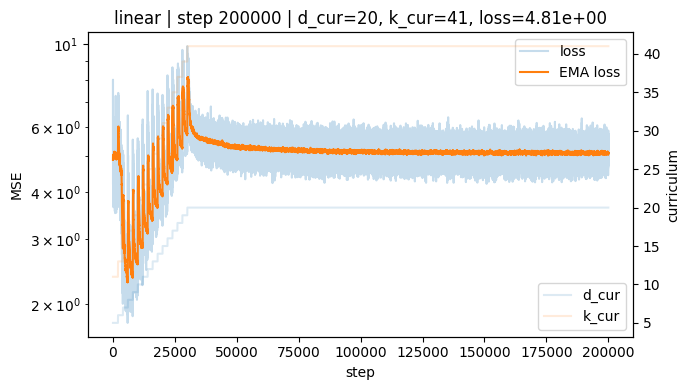

In [16]:
# simple EMA for nicer curve
beta = 0.98
ema = None

steps = []
losses = []
ema_losses = []
d_curs = []
k_curs = []

start = time.time()

trainer.model.train()

for step in range(cfg.total_steps):
    # curriculum schedule (d_cur, k_cur)
    d_cur, k_cur = trainer.curriculum.get(step)

    # generate batch
    batch = gen.sample_batch(
        task=cfg.task,
        batch_size=cfg.batch_size,
        k=k_cur,
        effective_dim=d_cur,
        sparse_s=sparse_s,
    )
    tokens = batch.tokens.to(device)
    targets = batch.targets.to(device)

    # forward + loss
    preds = trainer.model(tokens)
    loss = (preds - targets).pow(2).mean()

    # backward + update
    trainer.opt.zero_grad(set_to_none=True)
    loss.backward()
    if cfg.grad_clip and cfg.grad_clip > 0:
        torch.nn.utils.clip_grad_norm_(trainer.model.parameters(), cfg.grad_clip)
    trainer.opt.step()

    # record scalars (IMPORTANT: store Python floats only)
    loss_val = float(loss.detach().cpu())
    ema = loss_val if ema is None else beta * ema + (1 - beta) * loss_val

    steps.append(step)
    losses.append(loss_val)
    ema_losses.append(ema)
    d_curs.append(d_cur)
    k_curs.append(k_cur)

    # print progress
    if (step + 1) % cfg.log_every == 0:
        elapsed = time.time() - start
        it_s = (step + 1) / elapsed
        print(f"step {step+1:>6} | d_cur={d_cur:>2} k_cur={k_cur:>3} | loss={loss_val:.3e} | {it_s:.1f} it/s")

    # live plot
    if (step + 1) % plot_every == 0:
        clear_output(wait=True)

        fig, ax1 = plt.subplots(figsize=(7, 4))
        ax1.plot(steps, losses, alpha=0.25, label="loss")
        ax1.plot(steps, ema_losses, label="EMA loss")
        ax1.set_yscale("log")
        ax1.set_xlabel("step")
        ax1.set_ylabel("MSE")
        ax1.legend(loc="upper right")

        ax2 = ax1.twinx()
        ax2.plot(steps, d_curs, alpha=0.15, label="d_cur")
        ax2.plot(steps, k_curs, alpha=0.15, label="k_cur")
        ax2.set_ylabel("curriculum")
        ax2.legend(loc="lower right")

        ax1.set_title(f"{cfg.task} | step {step+1} | d_cur={d_cur}, k_cur={k_cur}, loss={loss_val:.2e}")
        plt.tight_layout()
        plt.show()


In [17]:
import os
import torch

# where to save
save_dir = "saved_models"
os.makedirs(save_dir, exist_ok=True)

save_path = os.path.join(save_dir, "linear_icl_transformer.pt")

# save only what is needed to reload the model
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "d_in": d,
        "d_model": d_model,
        "n_layers": n_layers,
        "n_heads": n_heads,
        "max_seq_len": max_seq_len,
        "task": task,
    },
    save_path,
)

print(f"Model saved to: {save_path}")


Model saved to: saved_models\linear_icl_transformer.pt
